In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df=pd.read_csv('customer-churn.csv')
skipinitialspace=True
na_values=[""," ","NA", "?"]

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

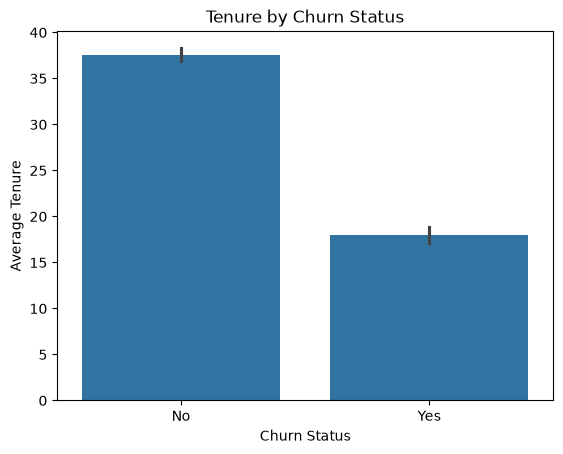

In [27]:
sns.barplot(x='Churn', y='tenure', data=df)
plt.xlabel('Churn Status')
plt.ylabel('Average Tenure')
plt.title('Tenure by Churn Status')
plt.show()

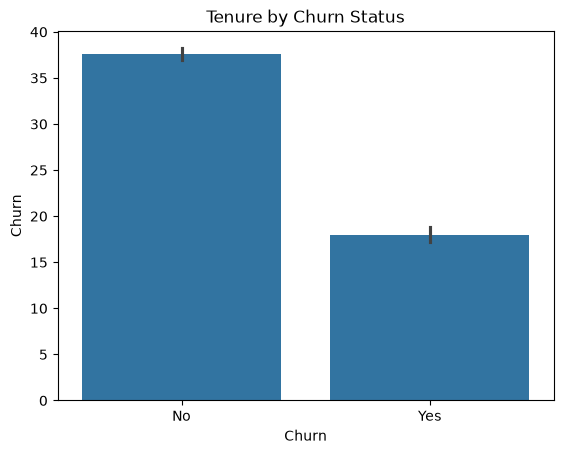

In [28]:
sns.barplot(x=df['Churn'], y=df['tenure'], data=df)
plt.xlabel('Churn')
plt.ylabel('Churn')
plt.title('Tenure by Churn Status')
plt.show()


In [33]:
# Calculate median first
median_charges = df['TotalCharges'].median()

# Assign back to the column
df['TotalCharges'] = df['TotalCharges'].fillna(median_charges)

In [29]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
#changing categorical variables to numerical variables using label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical__columns=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


for col in categorical__columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.model_selection import train_test_split

x=df.drop(['customerID', 'Churn'], axis=1)
y=df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#dropping irrelevant values
df.drop(['customerID', 'Churn'], axis=1, inplace=True)

